In [1]:
from utils import DQN, ReplayBuffer, greedy_action, epsilon_greedy, update_target, loss

import torch # ML library 
from torch import nn
import torch.nn.functional as F
import torch.optim as optim
import math
import numpy as np

import gym # provides various RL environments
import matplotlib.pyplot as plt

import os
import fnmatch
import logging 

In [40]:
# Logging configuration (put this right after imports)

# experiment_directory = "experiments" # CREATE THIS DIRECTORY BEFORE RUNNING THE CODE

# # Find existing log files and get the highest number
# existing_plots = fnmatch.filter(os.listdir(experiment_directory), 'plot_*.png')
# if existing_plots:
#     existing_numbers = [int(plot.split('_')[1].split('.')[0]) for plot in existing_plots]
#     plot_number = max(existing_numbers) + 1
# else:
#     plot_number = 1
    
# logging.basicConfig(filename=f"experiments/training_log.log",
#                     level=logging.INFO,
#                     format='%(asctime)s - %(levelname)s - %(message)s'
#                     )



In [3]:
# Parameters 
NUM_RUNS = 1
initial_lr = 1
num_episodes = 300
batch_size = 128
buffer_size = 100000
update_period = 15
decay_rate = 0.98 # for epsilon
initial_epsilon = 1
min_epsilon = 0.1
min_alpha = 0.001

In [4]:
runs_results = []

env = gym.make('CartPole-v1')

plt.figure(figsize=(9, 4)) # width:height

for run in range(NUM_RUNS):
    print(f"Starting run {run+1} of {NUM_RUNS}")

    architecture = [4, 32, 32, 2] # 4 inputs and 2 outputs, 2 hidden layers
    policy_net = DQN(architecture) 
    target_net = DQN(architecture)
    update_target(target_net, policy_net)
    target_net.eval()
    
    # Parameters 
    lr = initial_lr
    EPSILON = initial_epsilon

    # Set the buffer size
    memory = ReplayBuffer(buffer_size) 

    steps_done = 0
    episode_durations = []

    
    for i_episode in range(num_episodes): 
        lr = max(min_alpha, lr*0.955) # decaying learning rate
        optimizer = optim.SGD(policy_net.parameters(), lr) # stochastic gradient descent, updated every episode with the new alpha
        if (i_episode+1) % 50 == 0:
            print("episode ", i_episode+1, "/", 300)

        observation, info = env.reset()
        state = torch.tensor(observation).float()

        done = False
        terminated = False
        t = 0

        EPSILON = max(EPSILON*decay_rate, min_epsilon) # decaying epsilon 
        while not (done or terminated):

            # Select and perform an action
            action = epsilon_greedy(EPSILON, policy_net, state)
            # action = greedy_action(policy_net, state) # can try without epsilon greedy 

            # reward is a scalar, [reward] creates a one-element list, which is converted into a tensor
            observation, reward, done, terminated, info = env.step(action)
            reward = torch.tensor([reward])
            action = torch.tensor([action])
            next_state = torch.tensor(observation).reshape(-1).float()

            # store in replay buffer
            memory.push([state, action, next_state, reward, torch.tensor([done])])

            # Move to the next state
            state = next_state

            # Perform one step of the optimization (on the policy network)
            if not len(memory.buffer) < batch_size: # only proceed if enough data in buffer 
                transitions = memory.sample(batch_size) # sample N transition from buffer, where N = batch size
                state_batch, action_batch, nextstate_batch, reward_batch, dones = (torch.stack(x) for x in zip(*transitions)) # and unpack
                # Compute loss
                mse_loss = loss(policy_net, target_net, state_batch, action_batch, reward_batch, nextstate_batch, dones)
                # Optimize the model
                optimizer.zero_grad() # from optimizer, reset gradient to prep for new step 
                mse_loss.backward() # store gradient of the loss wrt each para 
                optimizer.step() # carry out gradient dedscent step & update of para 
            
            if done or terminated:
                episode_durations.append(t + 1)
            t += 1
        # Update the target network, copying all weights and biases in DQN
        if i_episode % update_period == 0: 
            update_target(target_net, policy_net)
    runs_results.append(episode_durations)
print('Complete')

Starting run 1 of 1


C:\Users\yhara\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\gym\utils\passive_env_checker.py:233: DeprecationWarning: `np.bool8` is a deprecated alias for `np.bool_`.  (Deprecated NumPy 1.24)
  if not isinstance(terminated, (bool, np.bool8)):


episode  50 / 300
episode  100 / 300
episode  150 / 300
episode  200 / 300
episode  250 / 300
episode  300 / 300
Complete


<Figure size 900x400 with 0 Axes>

413.09


NameError: name 'plot_number' is not defined

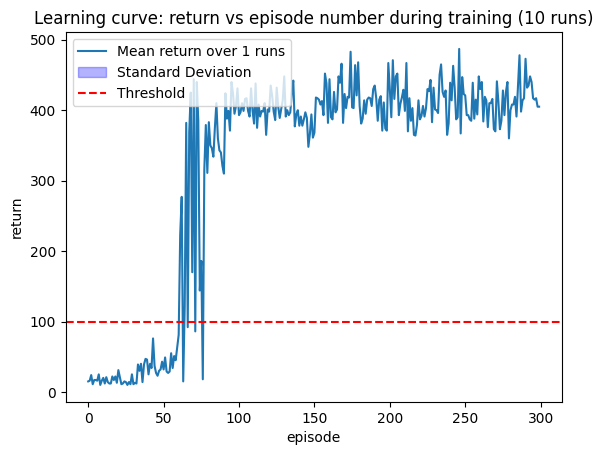

In [5]:
# Plotting the learning curve
# Placeholder plot, you are free to modify it
 
results = torch.tensor(runs_results)
means = results.float().mean(0) # mean of results calculated along axis 0
stds = results.float().std(0)

# To have a quantitative measure of the means and std
quantify_results = np.average(means[200:300])
quantify_std = np.average(stds[200:300])
print(quantify_results)

plt.plot(torch.arange(num_episodes), means, label=f"Mean return over {NUM_RUNS} runs")
plt.title("Learning curve: return vs episode number during training (10 runs)")
plt.ylabel("return")
plt.xlabel("episode")
plt.fill_between(np.arange(num_episodes), means, means+stds, alpha=0.3, color='b', label=f"Standard Deviation")
plt.fill_between(np.arange(num_episodes), means, means-stds, alpha=0.3, color='b')
plt.axhline(y=100, color='r', linestyle='--', label='Threshold')
plt.legend(loc = 'upper left')  # Add a legend to label the threshold line
plt.savefig(f'experiments/plot_{plot_number}.png') # ADD THIS LINE TO SAVE THE PLOT IN THE EXPERIMENTS DIRECTORY
# plt.savefig("C:/Users/yhara/OneDrive - Imperial College London/YEAR 4/RL/Figure3.svg",  format = 'svg') # to save as an svg

plt.show()


In [45]:
logging.info(f"Hyperparameters: plot_number={plot_number}, NUM_RUNS={NUM_RUNS}, NUM_EP={num_episodes}, INITIAL_EPSILON={initial_epsilon}, BUFFER_SIZE={buffer_size} EPSILON_DECAY_RATE={decay_rate}, UPDATE_PERIOD={update_period}, BATCH_SIZE={batch_size}, ALPHA={lr}, LAYER_SIZES={layer_size}, QUANTIFY_MEAN={quantify_results}, QUANTIFY_STD={quantify_std}")

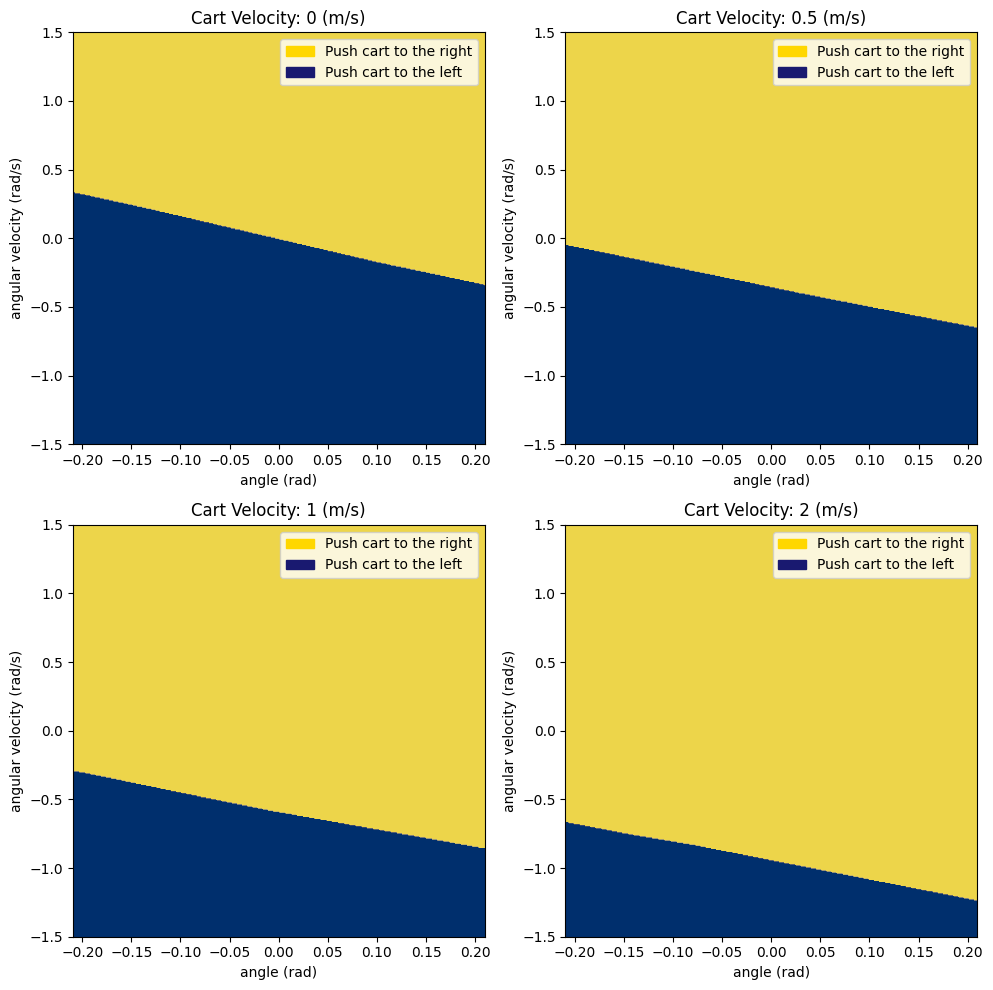

In [113]:
# Visualising the greedy Q-values for a stationary cart in the middle of the track
# 2D plot showing policy as a function of pole angle and angular velocity (omega)

# This plots the policy and Q values according to the network currently
# stored in the variable "policy_net"

# All visualisations provided here are placeholders and you can modify these plots
# Make sure to include appropriate labels and/or legends when presenting your plot

import matplotlib.patches as mpatches

q = False    # set to True if want the q values, False if greedy policy 

angle_range = .2095 # you may modify this range
omega_range = 1.5     # you may modify this range

angle_samples = 400 # was originially 100 
omega_samples = 400
angles = torch.linspace(angle_range, -angle_range, angle_samples) # 100 samples between -0.2095 and +0.2095 
omegas = torch.linspace(-omega_range, omega_range, omega_samples)

velocities = [0, 0.5, 1, 2]

fig, axs = plt.subplots(2, 2, figsize=(10, 10))

for idx, velocity in enumerate(velocities):
    greedy_q_array = torch.zeros((angle_samples, omega_samples))
    policy_array = torch.zeros((angle_samples, omega_samples))

    for i, angle in enumerate(angles):
        for j, omega in enumerate(omegas):
            state = torch.tensor([0, velocity, angle, omega])
            with torch.no_grad():
                q_vals = policy_net(state)
                greedy_action = q_vals.argmax()
                greedy_q_array[i, j] = q_vals[greedy_action]
                policy_array[i, j] = greedy_action
    if q:
        im = axs[idx // 2, idx % 2].contourf(angles, omegas, greedy_q_array.T, cmap='cividis', levels=100)
        cbar = fig.colorbar(im, ax=axs[idx // 2, idx % 2])
    
    else:
        im = axs[idx // 2, idx % 2].contourf(angles, omegas, policy_array.T, cmap='cividis')
        legend_patches = [mpatches.Patch(color = 'gold', label = 'Push cart to the right'), mpatches.Patch(color='midnightblue', label = 'Push cart to the left')]
        axs[idx // 2, idx % 2].legend(handles=legend_patches, loc='upper right')

        
    # axs[idx // 2, idx % 2].legend(handles=legend_patches, loc='upper right')

    axs[idx // 2, idx % 2].set_xlabel("angle (rad)")
    axs[idx // 2, idx % 2].set_ylabel("angular velocity (rad/s)")
    axs[idx // 2, idx % 2].set_title(f"Cart Velocity: {velocity} (m/s)")
    

plt.tight_layout()
plt.show()


Heatmap for the architecture

In [ ]:
# pip install seaborn

In [ ]:
# Parameters 
NUM_RUNS = 3
num_episodes = 300
batch_size = 128
buffer_size = 100000
update_period = 15
decay_rate = 0.98
initial_epsilon = 1
initial_alpha = 1
min_epsilon = 0.1
min_alpha = 0.01

In [ ]:

env = gym.make('CartPole-v1')

# Assuming runs_results is defined
runs_results = []

# Define the parameters
number_layers = [0, 1, 2, 3]
# size_layers = [10, 30, 50]
size_layers = [32, 64, 128, 256, 512]

# Create a matrix to store the mean episode durations for different configurations
mean_durations = np.zeros((len(number_layers), len(size_layers)))

for i, number in enumerate(number_layers):
    for j, size in enumerate(size_layers):
        # Assuming runs_results contains lists of episode durations
        # Calculate mean of the episode durations for each configuration of buffer_size and batch_size
        for run in range(NUM_RUNS):
            print(f"Starting run {run+1} of {NUM_RUNS}")

            architecture = [4, *[size]*number, 2]
            policy_net = DQN(architecture) # input = 4 and output = 2 (0 or 1) 
            target_net = DQN(architecture)
            update_target(target_net, policy_net)
            target_net.eval()
            
            # Layer size
            layer_size = architecture[1]

    
            # optimizer = optim.Adam(policy_net.parameters(), lr=learning_rate)
            memory = ReplayBuffer(buffer_size) # 1 originally 

            steps_done = 0

            episode_durations = []

            # EPSILON = 0.2
            EPSILON = initial_epsilon
            lr = initial_alpha

            for i_episode in range(num_episodes): # can adjust num_episodes 
                lr = max(min_alpha, lr*0.955)
                optimizer = optim.SGD(policy_net.parameters(), lr)

                EPSILON = max(min_epsilon, EPSILON*decay_rate)
                if (i_episode+1) % 50 == 0:
                    print("episode ", i_episode+1, "/", 300)

                observation, info = env.reset()
                state = torch.tensor(observation).float()

                done = False
                terminated = False
                t = 0
                while not (done or terminated):

                    # Select and perform an action
                    action = epsilon_greedy(EPSILON, policy_net, state)
                    # action = greedy_action(policy_net, state) # can try without epsilon greedy 

                    # reward is a scalar, [reward] creates a one-element list, which is converted into a tensor
                    observation, reward, done, terminated, info = env.step(action)
                    reward = torch.tensor([reward])
                    action = torch.tensor([action])
                    next_state = torch.tensor(observation).reshape(-1).float()

                    # store in replay buffer
                    memory.push([state, action, next_state, reward, torch.tensor([done])])

                    # Move to the next state
                    state = next_state

                    # Perform one step of the optimization (on the policy network)
                    if not len(memory.buffer) < batch_size: # only proceed if enough data in buffer 
                        transitions = memory.sample(batch_size) # sample one transition from buffer
                        state_batch, action_batch, nextstate_batch, reward_batch, dones = (torch.stack(x) for x in zip(*transitions)) # and unpack
                        # Compute loss
                        mse_loss = loss(policy_net, target_net, state_batch, action_batch, reward_batch, nextstate_batch, dones)
                        # Optimize the model
                        optimizer.zero_grad() # from optimizer, reset gradient to prep for new step 
                        mse_loss.backward() # store gradient of the loss wrt each para 
                        optimizer.step() # carry out gradient dedscent step & update of para 
                    
                    if done or terminated:
                        episode_durations.append(t + 1)
                    t += 1
                # Update the target network, copying all weights and biases in DQN
                if i_episode % update_period == 0: 
                    update_target(target_net, policy_net)
            runs_results.append(episode_durations)
        print('Complete')

        mean_duration = np.mean([np.mean(run[150:300]) for run in runs_results])
        mean_durations[i][j] = mean_duration


In [ ]:
# Create subplots
fig, ax = plt.subplots(figsize=(8, 6))

# Create a heatmap using Seaborn on Matplotlib
sns.heatmap(mean_durations, annot=True, fmt=".2f", cmap='viridis', xticklabels=size_layers, yticklabels=number_layers, ax=ax)

# Setting labels, ticks, and title
ax.set_title('Effect of varying the Number and Size of Hidden Layers: mean return over 3 runs')
ax.set_xlabel('Size of hidden layers')
ax.set_ylabel('Number of hidden layers')

# Get the current Axes instance on the current figure
cax = plt.gcf().axes[-1]

# Create a colorbar for the entire figure
cbar = plt.colorbar(ax.collections[0], cax=cax)
cbar.set_label('Mean Return')

plt.tight_layout()
plt.show()

Heatmap Batch Buffer

In [ ]:
# Parameters 
NUM_RUNS = 3
EPSILON = 0.1     # placeholder value - you should implement your own exploration schedule
lr = 0.01
num_episodes = 300
batch_size = 32
buffer_size = 100000
update_period = 15
decay_rate = 0.995
initial_epsilon = 1
min_epsilon = 0.1

In [ ]:

env = gym.make('CartPole-v1')

# Assuming runs_results is defined
runs_results = []

# Define the parameters
batch_sizes = [16, 32, 64, 128]  # Adjust these values as needed
buffer_sizes = [100, 1000, 10000, 100000]  # Adjust these values as needed

# Create a matrix to store the mean episode durations for different configurations
mean_durations = np.zeros((len(buffer_sizes), len(batch_sizes)))

for i, buffer_size in enumerate(buffer_sizes):
    for j, batch_size in enumerate(batch_sizes):
        # Assuming runs_results contains lists of episode durations
        # Calculate mean of the episode durations for each configuration of buffer_size and batch_size
        for run in range(NUM_RUNS):
            print(f"Starting run {run+1} of {NUM_RUNS}")

            architecture = [4, 50, 50, 2]
            policy_net = DQN(architecture) # input = 4 and output = 2 (0 or 1) 
            target_net = DQN(architecture)
            update_target(target_net, policy_net)
            target_net.eval()
            
            # Layer size
            layer_size = architecture[1]

            optimizer = optim.SGD(policy_net.parameters(), lr) # stochastic gradient descent, learning rate
            # optimizer = optim.Adam(policy_net.parameters(), lr=learning_rate)
            memory = ReplayBuffer(buffer_size) # 1 originally 

            steps_done = 0

            episode_durations = []

            EPSILON = initial_epsilon

            for i_episode in range(num_episodes): # can adjust num_episodes 
                if (i_episode+1) % 50 == 0:
                    print("episode ", i_episode+1, "/", 300)

                observation, info = env.reset()
                state = torch.tensor(observation).float()

                done = False
                terminated = False
                t = 0
                EPSILON = max(1/(i_episode+1), min_epsilon)
                while not (done or terminated):

                    # Select and perform an action
                    action = epsilon_greedy(EPSILON, policy_net, state)
                    # action = greedy_action(policy_net, state) # can try without epsilon greedy 

                    # reward is a scalar, [reward] creates a one-element list, which is converted into a tensor
                    observation, reward, done, terminated, info = env.step(action)
                    reward = torch.tensor([reward])
                    action = torch.tensor([action])
                    next_state = torch.tensor(observation).reshape(-1).float()

                    # store in replay buffer
                    memory.push([state, action, next_state, reward, torch.tensor([done])])

                    # Move to the next state
                    state = next_state

                    # Perform one step of the optimization (on the policy network)
                    if not len(memory.buffer) < batch_size: # only proceed if enough data in buffer 
                        transitions = memory.sample(batch_size) # sample one transition from buffer
                        state_batch, action_batch, nextstate_batch, reward_batch, dones = (torch.stack(x) for x in zip(*transitions)) # and unpack
                        # Compute loss
                        mse_loss = loss(policy_net, target_net, state_batch, action_batch, reward_batch, nextstate_batch, dones)
                        # Optimize the model
                        optimizer.zero_grad() # from optimizer, reset gradient to prep for new step 
                        mse_loss.backward() # store gradient of the loss wrt each para 
                        optimizer.step() # carry out gradient dedscent step & update of para 
                    
                    if done or terminated:
                        episode_durations.append(t + 1)
                    t += 1
                # Update the target network, copying all weights and biases in DQN
                if i_episode % update_period == 0: 
                    update_target(target_net, policy_net)
            runs_results.append(episode_durations)
        print('Complete')

        mean_duration = np.mean([np.mean(run[200:300]) for run in runs_results])
        # mean_duration = np.std([np.mean(run[200:300]) for run in runs_results])
        mean_durations[i][j] = mean_duration


In [ ]:
# Create subplots
fig, ax = plt.subplots(figsize=(8, 6))

# Create a heatmap using Seaborn on Matplotlib
sns.heatmap(mean_durations, annot=True, fmt=".2f", cmap='viridis', xticklabels=batch_sizes, yticklabels=buffer_sizes, ax=ax)

# Setting labels, ticks, and title
ax.set_title('Effect of varying the Batch Size and Buffer Size: mean return over 3 runs') #CHANGE STD 
ax.set_xlabel('Batch Size')
ax.set_ylabel('Buffer Size')

# Get the current Axes instance on the current figure
cax = plt.gcf().axes[-1]

# Create a colorbar for the entire figure
cbar = plt.colorbar(ax.collections[0], cax=cax)
cbar.set_label('Mean Return')

plt.tight_layout()
plt.show()

Hyperparameter Sweep

In [114]:
# Parameters 
NUM_RUNS = 3
num_episodes = 300

# !pip install wandb -Uq
import wandb
wandb.login()

# Intialise
sweep_config = {
    'method': 'random'
    }

metric = {
    'name': 'mean_return',
    'goal': 'maximize'   
    }

sweep_config['metric'] = metric

# Constant parameters 
parameters_dict = {
    'optimizer': {
        'values': ['adam', 'sgd']
        },
    'BATCH_SIZE': {
        'values': [16, 32, 64, 128]
        },
    'BUFFER_SIZE':{
        'values': [100, 1000, 10000, 100000]
        },
    'UPDATE_PERIOD':{
        'values': [1, 10, 15]
    },
    'NUMBER_HIDDEN_LAYERS':{
        'values': [0, 1, 2, 3]
    },
    'SIZE_HIDDEN_LAYER':{
        'values': [32, 64, 128, 256, 512]
    },
    }

sweep_config['parameters'] = parameters_dict

# Variable parameters
parameters_dict.update({
    'LEARNING_RATE': {
        'distribution': 'uniform',
        'min': 0,
        'max': 1},
    'EPSILON': {
        'distribution': 'uniform',
        'min': 0,
        'max': 1},
    })

import pprint
pprint.pprint(sweep_config)

In [ ]:
sweep_id = wandb.sweep(sweep_config, project="pytorch-hyperpara-sweeps")

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


def train(config=None):
    # Initialize a new wandb run
    with wandb.init(config=config):
        # If called by wandb.agent, as below,
        # this config will be set by Sweep Controller
        config = wandb.config
        

        buffer_size = config.BUFFER_SIZE
        batch_size = config.BATCH_SIZE
        update_period = config.UPDATE_PERIOD
        size_inner_layer = config.SIZE_HIDDEN_LAYER
        number_inner_layers = config.NUMBER_HIDDEN_LAYERS
        lr = config.LEARNING_RATE
        epsilon = config.EPSILON

        #######
        runs_results = []

        env = gym.make('CartPole-v1')
        for run in range(NUM_RUNS):
            print(f"Starting run {run+1} of {NUM_RUNS}")

            architecture = [4, *[size_inner_layer]*number_inner_layers, 2]
            policy_net = DQN(architecture) # input = 4 and output = 2 (0 or 1) 
            target_net = DQN(architecture)
            update_target(target_net, policy_net)
            target_net.eval()
    
            optimizer = build_optimizer(policy_net, config.optimizer, lr)
            memory = ReplayBuffer(buffer_size) # 1 originally 

            steps_done = 0

            episode_durations = []

            for i_episode in range(num_episodes): # can adjust num_episodes 
                if (i_episode+1) % 50 == 0:
                    print("episode ", i_episode+1, "/", 300)

                observation, info = env.reset()
                state = torch.tensor(observation).float()

                done = False
                terminated = False
                t = 0
                # EPSILON = max(1/(i_episode+1), min_epsilon)
                while not (done or terminated):

                    # Select and perform an action
                    action = epsilon_greedy(epsilon, policy_net, state)
                    # action = greedy_action(policy_net, state) # can try without epsilon greedy 

                    # reward is a scalar, [reward] creates a one-element list, which is converted into a tensor
                    observation, reward, done, terminated, info = env.step(action)
                    reward = torch.tensor([reward])
                    action = torch.tensor([action])
                    next_state = torch.tensor(observation).reshape(-1).float()

                    # store in replay buffer
                    memory.push([state, action, next_state, reward, torch.tensor([done])])

                    # Move to the next state
                    state = next_state

                    # Perform one step of the optimization (on the policy network)
                    if not len(memory.buffer) < batch_size: # only proceed if enough data in buffer 
                        transitions = memory.sample(batch_size) # sample one transition from buffer
                        state_batch, action_batch, nextstate_batch, reward_batch, dones = (torch.stack(x) for x in zip(*transitions)) # and unpack
                        # Compute loss
                        mse_loss = loss(policy_net, target_net, state_batch, action_batch, reward_batch, nextstate_batch, dones)
                        # Optimize the model
                        optimizer.zero_grad() # from optimizer, reset gradient to prep for new step 
                        mse_loss.backward() # store gradient of the loss wrt each para 
                        optimizer.step() # carry out gradient dedscent step & update of para 
                    
                    if done or terminated:
                        episode_durations.append(t + 1)
                    t += 1
                # Update the target network, copying all weights and biases in DQN
                if i_episode % update_period == 0: 
                    update_target(target_net, policy_net)
            runs_results.append(episode_durations)
            print('log')
            wandb.log({"mean_return": np.mean(episode_durations[150:300])})
        print('Complete')


def build_optimizer(policy, optimizer, lr):
    if optimizer == "sgd":
        optimizer = optim.SGD(policy.parameters(),
                              lr) # removed momentum 
    elif optimizer == "adam":
        optimizer = optim.Adam(policy.parameters(),
                               lr)
    return optimizer            

Overlap plots (only for epsilon, but same structure for other parameters)

In [ ]:
# Parameters 
NUM_RUNS = 3
# placeholder value - you should implement your own exploration schedule
num_episodes = 300
batch_size = 128
buffer_size = 100000
update_period = 15
decay_rate = 0.98 # for epsilon
initial_epsilon = 1
min_epsilon = 0.1
min_alpha = 0.01

In [ ]:
epsilon_values = ['1/episode', 'decaying α', '0', '0.01', '0.1', '0.2', '1.0']  # Define the alpha values
env = gym.make('CartPole-v1') 

def moving_average(a, n=3):
    ret = np.cumsum(a, dtype=float)
    ret[n:] = ret[n:] - ret[:-n]
    return ret[n - 1:]/n
plt.figure(figsize=(8, 4)) # width:height

for epsilon_value in epsilon_values:
    runs_results = []  # Reset runs_results for each epsilon value

    for run in range(NUM_RUNS):
        print(f"Starting run {run+1} of {NUM_RUNS}")

        architecture = [4, 50, 50, 2]
        policy_net = DQN(architecture) # input = 4 and output = 2 (0 or 1) 
        target_net = DQN(architecture)
        update_target(target_net, policy_net)
        target_net.eval()
        
        # Layer size
        layer_size = architecture[1] 

        # optimizer = optim.Adam(policy_net.parameters(), lr=learning_rate)
        memory = ReplayBuffer(buffer_size) # 1 originally 

        steps_done = 0

        episode_durations = []

        EPSILON = initial_epsilon  # Reset EPSILON for each epsilon value
        for i_episode in range(num_episodes):
            match (epsilon_value):
                case '1/episode': 
                    lr = max(1 / (i_episode + 1), min_alpha)
                case 'decaying α':
                    lr = max(lr*0.955, min_alpha)
                case '0':
                    lr = 0
                case '0.01':
                    lr = 0.01
                case '0.1':
                    lr = 0.1
                case '0.2':
                    lr = 0.2
                case '1.0':
                    lr = 1
            
            optimizer = optim.SGD(policy_net.parameters(), lr) # stochastic gradient descent, learning rate
            
            if (i_episode+1) % 50 == 0:
                print("episode ", i_episode+1, "/", 300)

            observation, info = env.reset()
            state = torch.tensor(observation).float()

            done = False
            terminated = False
            t = 0          
            
            # Decaying epsilon 
            EPSILON = max(min_epsilon, EPSILON*decay_rate) 

            # Rest of your code remains unchanged
            while not (done or terminated):

            # Select and perform an action
                action = epsilon_greedy(EPSILON, policy_net, state)
                # action = greedy_action(policy_net, state) # can try without epsilon greedy 

                # reward is a scalar, [reward] creates a one-element list, which is converted into a tensor
                observation, reward, done, terminated, info = env.step(action)
                reward = torch.tensor([reward])
                action = torch.tensor([action])
                next_state = torch.tensor(observation).reshape(-1).float()

                # store in replay buffer
                memory.push([state, action, next_state, reward, torch.tensor([done])])

                # Move to the next state
                state = next_state

                # Perform one step of the optimization (on the policy network)
                if not len(memory.buffer) < batch_size: # only proceed if enough data in buffer 
                    transitions = memory.sample(batch_size) # sample one transition from buffer
                    state_batch, action_batch, nextstate_batch, reward_batch, dones = (torch.stack(x) for x in zip(*transitions)) # and unpack
                    # Compute loss
                    mse_loss = loss(policy_net, target_net, state_batch, action_batch, reward_batch, nextstate_batch, dones)
                    # Optimize the model
                    optimizer.zero_grad() # from optimizer, reset gradient to prep for new step 
                    mse_loss.backward() # store gradient of the loss wrt each para 
                    optimizer.step() # carry out gradient dedscent step & update of para 
            
            
                if done or terminated:
                    episode_durations.append(t + 1)
                t += 1
            if i_episode % update_period == 0: 
                update_target(target_net, policy_net)

        runs_results.append(episode_durations)
    print('Complete')

    # Plotting learning curve for each epsilon value
    results = torch.tensor(runs_results)

    means = results.float().mean(0)
    means = [*means[:14], *moving_average(means, n=15)]
    stds = results.float().std(0)

    plt.plot(torch.arange(num_episodes), means, label=f"α = {epsilon_value}", linewidth = 0.8, alpha = 0.8)


plt.ylabel("return")
plt.xlabel("episode")
# plt.fill_between(np.arange(num_episodes), means, means + stds, alpha=0.3, color='b')
# plt.fill_between(np.arange(num_episodes), means, means - stds, alpha=0.3, color='b')
plt.axhline(y=100, color='r', linestyle='--', label='Threshold')
plt.legend(loc='upper left') 
plt.title('Learning Curve: return vs episode number during training for different α (5 runs)') # NUMBER OF RUNS
plt.show()